# High deceleration analysis

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# import sys
# sys.path.append(r'D:\CLARA\HALHF_at_CLARA\online_analysis')
# sys.path.append(r'D:\CLARA\HALHF_at_CLARA')


from HALHF_CLARA_analysis.CLARA_dataset import CLARADataset
from HALHF_CLARA_analysis.utils.colors import FLASHForward as FF_cmap
from HALHF_CLARA_analysis.plotting import plot_grouped_waterfall , plot_grouped_spectra_waterfall



In [2]:
#%% set plot styles
import matplotlib as mpl

mpl.rcParams["figure.figsize"] = (12, 6)
mpl.rc("xtick", labelsize=16)
mpl.rc("ytick", labelsize=16)
mpl.rc("font", size=18)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=["navy", "orange", "mediumseagreen", "dodgerblue", "blueviolet", "gold"]
)

norm = lambda x , xa : (x-np.min(xa))/(np.max(xa)-np.min(xa))

In [3]:
ESPEC_px2mm = 0.0453 #mm/px
ESPEC_Dx_design = 620 #mm
ESPEC_Dx_meas = 752 #mm
E0 = 250 # MeV

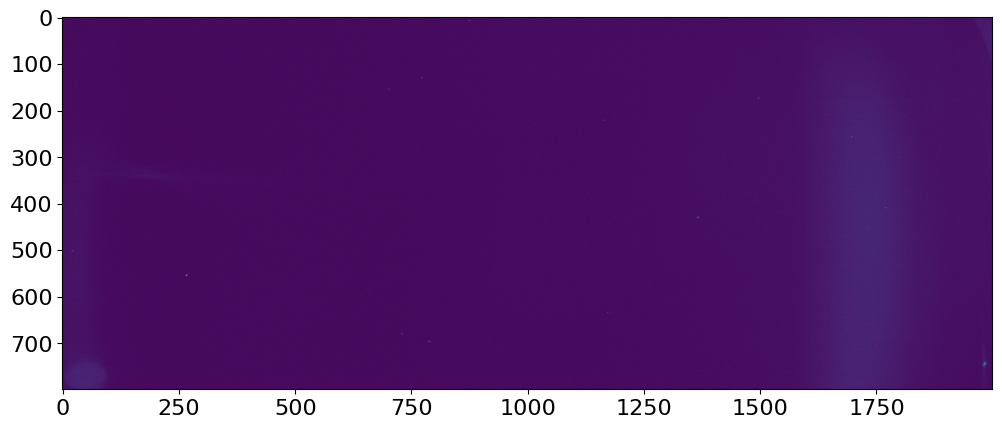

In [4]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\10\MultiSourceDAQ_20260410_160541.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\10\\')
data = dset.load_data(['CLA-FED-DIA-CAM-02'])
bg_image = data['CLA-FED-DIA-CAM-02'].iloc[0]

plt.figure()
plt.imshow(bg_image)

In [5]:
E_offset = 0

dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\10\MultiSourceDAQ_20260410_162217.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\10\\' , scope_dir = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\10\\')
print(dset.file['Comment'][()])

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [im - bg_image for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

plasma_off_im = data[data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] == 450].ESPEC.iloc[0]


b'PWFA: 250pC, after decreasing dipole strength , discharge timing scan, coarse'


In [6]:
E_offset = 0

dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\10\MultiSourceDAQ_20260410_163023.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\10\\' , scope_dir = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\10\\')
print(dset.file['Comment'][()])

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [im - bg_image for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

b'PWFA: 250pC, after decreasing dipole strength , discharge timing scan, fine, after optimsiing imaging again'


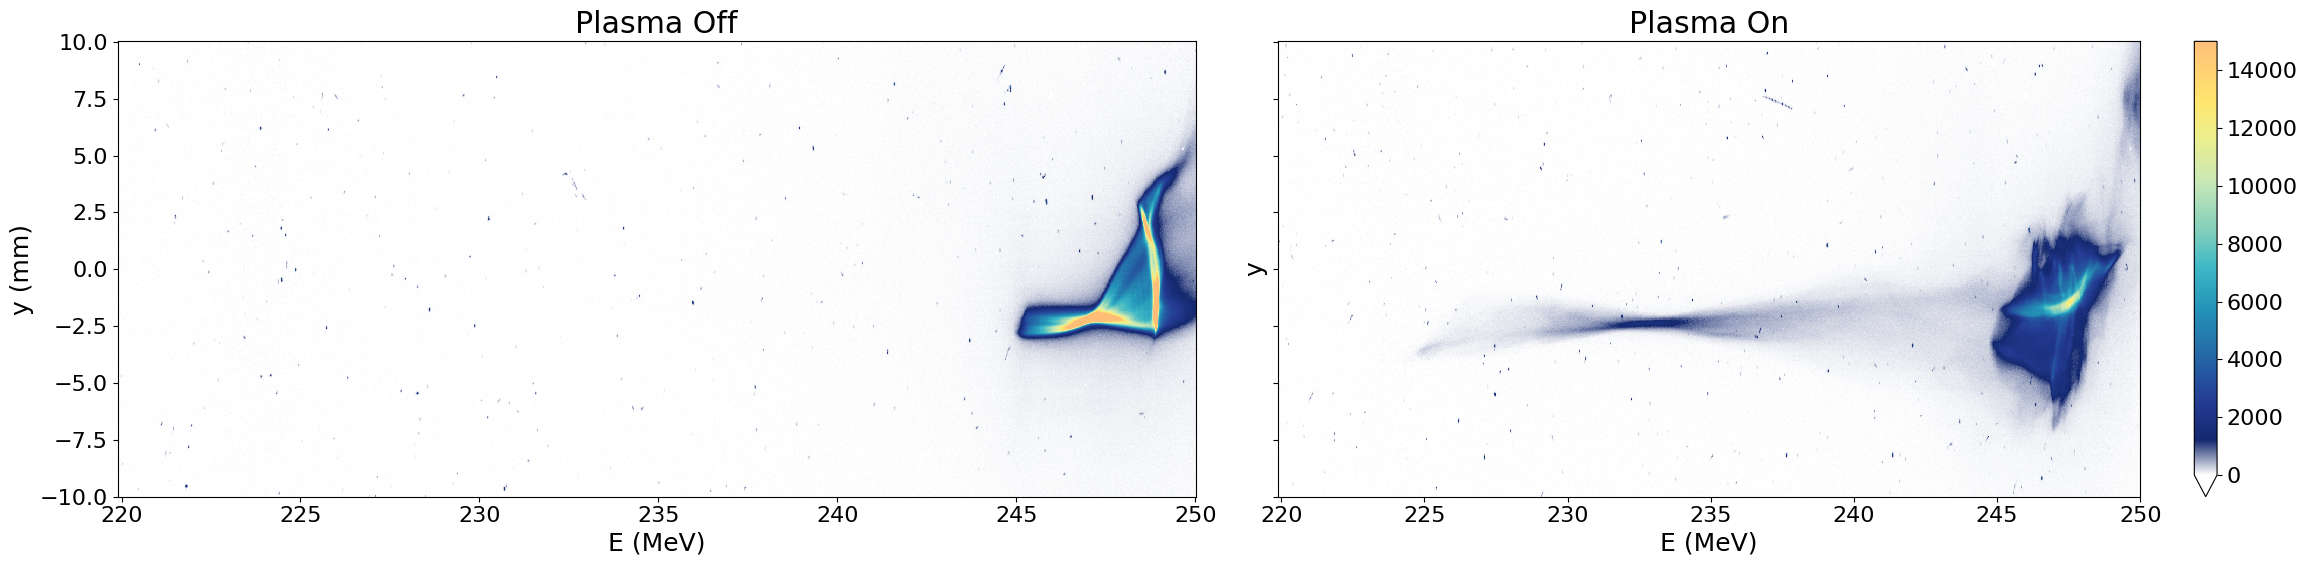

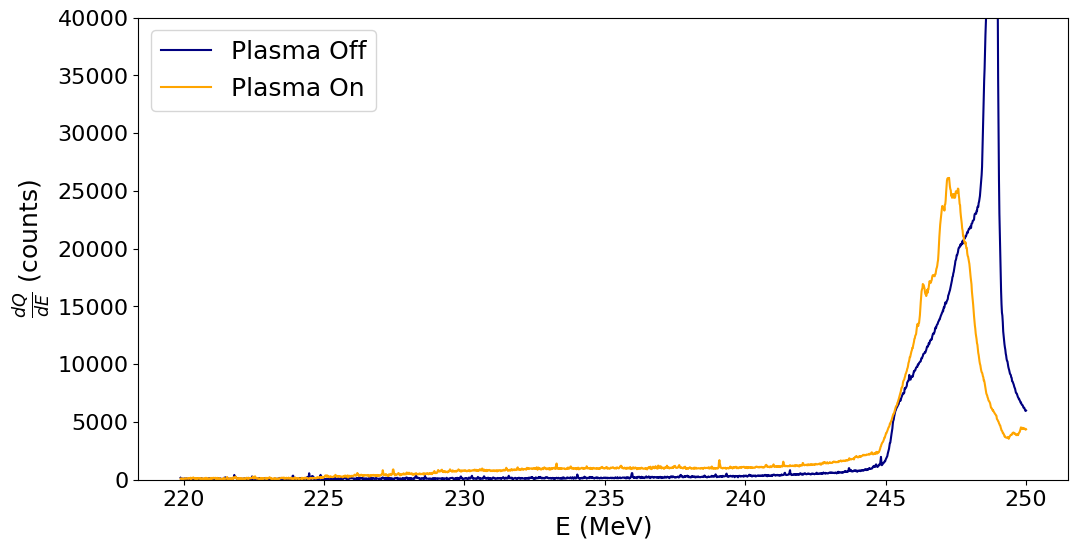

In [20]:
fig , axs = plt.subplots(ncols = 2 , sharey = True , figsize = (24,6))

fig_spec , ax_spec = plt.subplots()

im = plasma_off_im
im = xr.DataArray(im , coords = {'y' : np.arange(0 , im.shape[0] , 1) , 'E' : np.arange(0 , im.shape[1] , 1)})
im['E'] = im.E * ESPEC_px2mm - E_offset
im['E'] = -im.E / ESPEC_Dx_meas
im['E'] = E0 * (1 + im.E)
im['y'] = im.y * ESPEC_px2mm - 17.5
im = im.loc[-10:10]

im.plot(ax = axs[0] , cmap = FF_cmap , add_colorbar = False , vmin = 0 , vmax = 15000)
# axs[0].set_title(f't = 450 us')
axs[0].set_xlabel('E (MeV)')
axs[0].set_ylabel('y (mm)')
axs[0].set_title('Plasma Off')

im.integrate('y').plot(ax = ax_spec , label = 'Plasma Off')

im = data[data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] == 447].ESPEC.iloc[0]
im = xr.DataArray(im , coords = {'y' : np.arange(0 , im.shape[0] , 1) , 'E' : np.arange(0 , im.shape[1] , 1)})
im['E'] = im.E * ESPEC_px2mm - E_offset
im['E'] = -im.E / ESPEC_Dx_meas
im['E'] = E0 * (1 + im.E)
im['y'] = im.y * ESPEC_px2mm - 17.5
im = im.loc[-10:10]

im.plot(ax = axs[-1] , cmap = FF_cmap , add_colorbar = True , vmin = 0 , vmax = 15000)
# axs[-1].set_title(f't = 440 us')
axs[-1].set_xlabel('E (MeV)')
axs[-1].set_title('Plasma On')

fig.tight_layout()

im.integrate('y').plot(ax = ax_spec , label = 'Plasma On')
ax_spec.set_xlabel('E (MeV)')
ax_spec.set_ylabel(r'$\frac{dQ}{dE}$ (counts)')
ax_spec.set_ylim(0 , 40000)
ax_spec.legend()

In [39]:
centroid_energies = [np.average(im.E , weights = spec) for spec in data.xprof]
# rms_energies = [np.std(im.E , weights = spec) for spec in data.xprof]

In [40]:
specs_sorted = data.xprof.iloc[np.argsort(centroid_energies)]

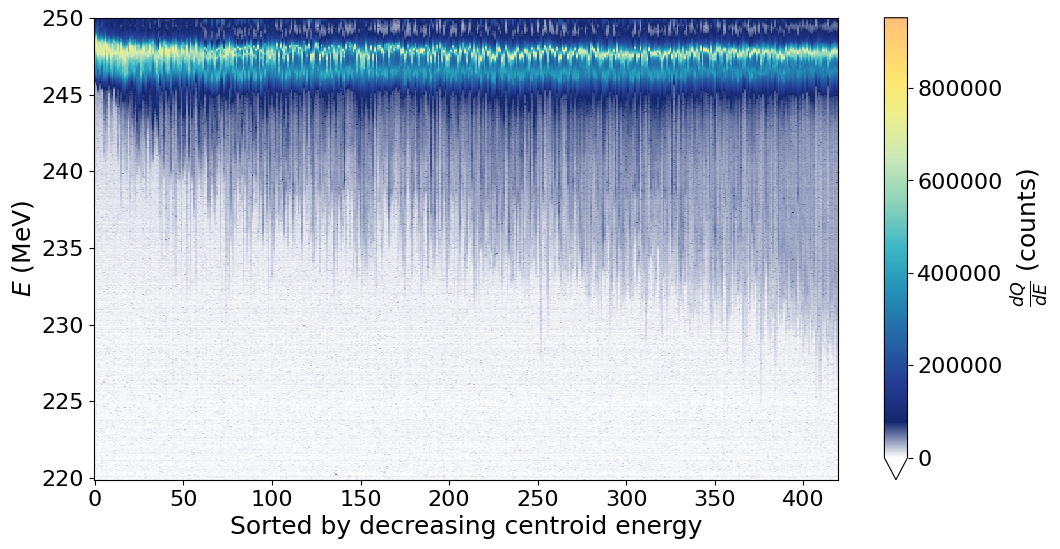

In [54]:
plt.figure()

# im = xr.DataArray(im , coords = {'y' : np.arange(0 , im.shape[0] , 1) , 'E' : np.arange(0 , im.shape[1] , 1)})
wf= np.stack(specs_sorted).transpose()[: ,::-1]
wf = xr.DataArray(wf , coords = {'E' : np.arange(0 , wf.shape[0] , 1) , 'shots' : np.arange(0 , wf.shape[1] , 1)})

wf['E'] = wf.E * ESPEC_px2mm - E_offset
wf['E'] = -wf.E / ESPEC_Dx_meas
wf['E'] = E0 * (1 + wf.E)

im = wf.plot(vmin = 0 , cmap = FF_cmap)

plt.xlabel('Sorted by decreasing centroid energy')
plt.ylabel('$E$ (MeV)')
im.colorbar.set_label(r'$\frac{dQ}{dE}$ (counts)')


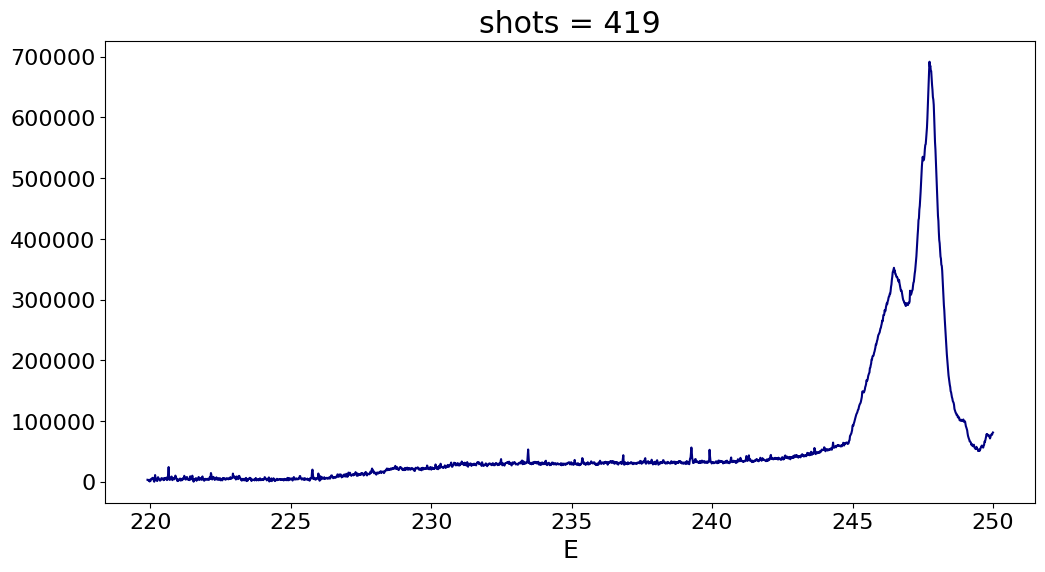

In [56]:
wf[:,-1].plot()

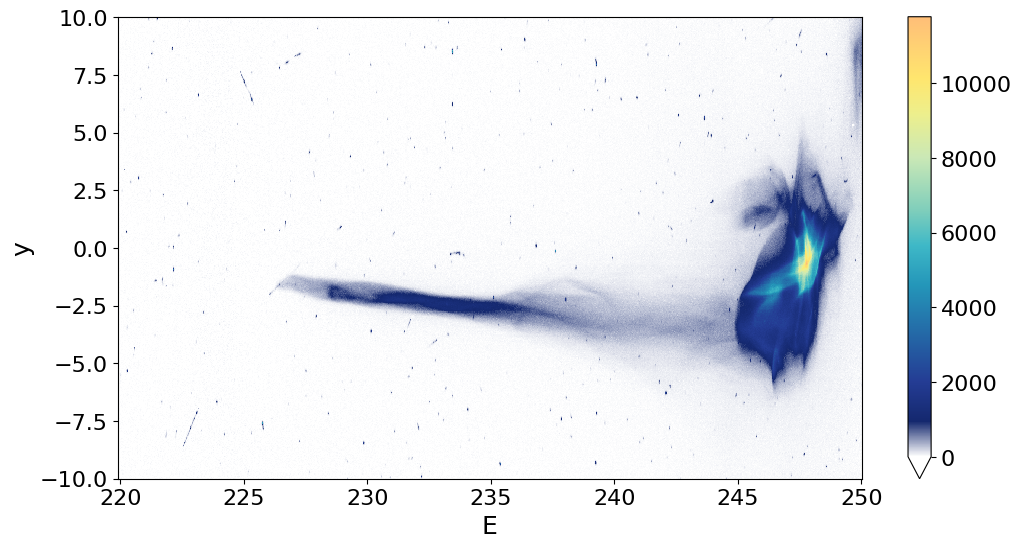

In [64]:


im_best = data.ESPEC.iloc[np.argmin(centroid_energies)]
im_best = xr.DataArray(im_best , coords = {'y' : np.arange(0 , im_best.shape[0] , 1) , 'E' : np.arange(0 , im_best.shape[1] , 1)})
im_best['E'] = im_best.E * ESPEC_px2mm - E_offset
im_best['E'] = -im_best.E / ESPEC_Dx_meas
im_best['E'] = E0 * (1 + im_best.E)
im_best['y'] = im_best.y * ESPEC_px2mm - 17.5
im_best = im_best.loc[-10:10]

im_best.plot(ax = axs[0] , cmap = FF_cmap , add_colorbar = False , vmin = 0 , vmax = 15000)
# axs[0].set_title(f't = 450 us')
axs[0].set_xlabel('E (MeV)')
axs[0].set_ylabel('y (mm)')
axs[0].set_title('Plasma Off')

im_best.plot(vmin = 0 , cmap = FF_cmap)